# Exercise 4 — Image Sharpening of the Chandrayaan-2 Moon Image

Student: Konstantinos Kritsotakis

Registration Number: 7115152500007  

Course: Image Analysis and Processing (2025–2026) 

## Objective

The goal of this exercise is to propose and implement a suitable method for sharpening the image:

**`First-photo-of-the-moon-from-Chandrayaan-2_ISRO.jpg`**

The image shows the lunar surface. It contains many small-scale structures, such as crater borders, local shadows, surface texture, and fine brightness transitions. These structures correspond mainly to **high spatial frequencies**, because the intensity changes rapidly over short spatial distances.

A suitable sharpening method should therefore enhance high-frequency image details while avoiding excessive amplification of noise or artificial artifacts.

For this reason, the proposed main method is:

## Unsharp Masking / High-Boost Filtering

Unsharp masking is a classical spatial-domain sharpening technique. Its main idea is to separate the image into a smooth low-frequency component and a high-frequency detail component.

Let the original grayscale image be:

$$
I(x,y)
$$

A blurred version of the image is obtained using Gaussian filtering:

$$
I_{\text{blur}}(x,y)=G_{\sigma}(x,y)\ast I(x,y)
$$

where:

- $G_{\sigma}(x,y)$ is a Gaussian kernel,
- $\sigma$ controls the amount of blurring,
- $\ast$ denotes convolution.

The blurred image contains mainly the **low-frequency component** of the image, meaning the slowly varying brightness information.

The high-frequency detail mask is then computed as:

$$
M(x,y)=I(x,y)-I_{\text{blur}}(x,y)
$$

This mask contains mainly edges, crater borders, fine surface texture, and local brightness transitions.

The final sharpened image is obtained by adding an amplified version of this detail mask back to the original image:

$$
I_{\text{sharp}}(x,y)=I(x,y)+kM(x,y)
$$

Substituting the expression for $M(x,y)$ gives:

$$
I_{\text{sharp}}(x,y)=I(x,y)+k\left[I(x,y)-I_{\text{blur}}(x,y)\right]
$$

Equivalently:

$$
I_{\text{sharp}}(x,y)=(1+k)I(x,y)-kI_{\text{blur}}(x,y)
$$

where:

- $k>0$ controls the strength of sharpening,
- larger $k$ gives stronger sharpening,
- larger $\sigma$ produces a more blurred low-frequency image and may enhance broader structures, but it can also create halo artifacts if it is too large.

For this moon image, the selected parameters are:

$$
\sigma=1.2
$$

and:

$$
k=1.3
$$

These values provide moderate sharpening: crater edges and lunar surface texture are enhanced, while the result remains visually controlled and avoids excessive halos or noise amplification.

The implementation below follows exactly this method.

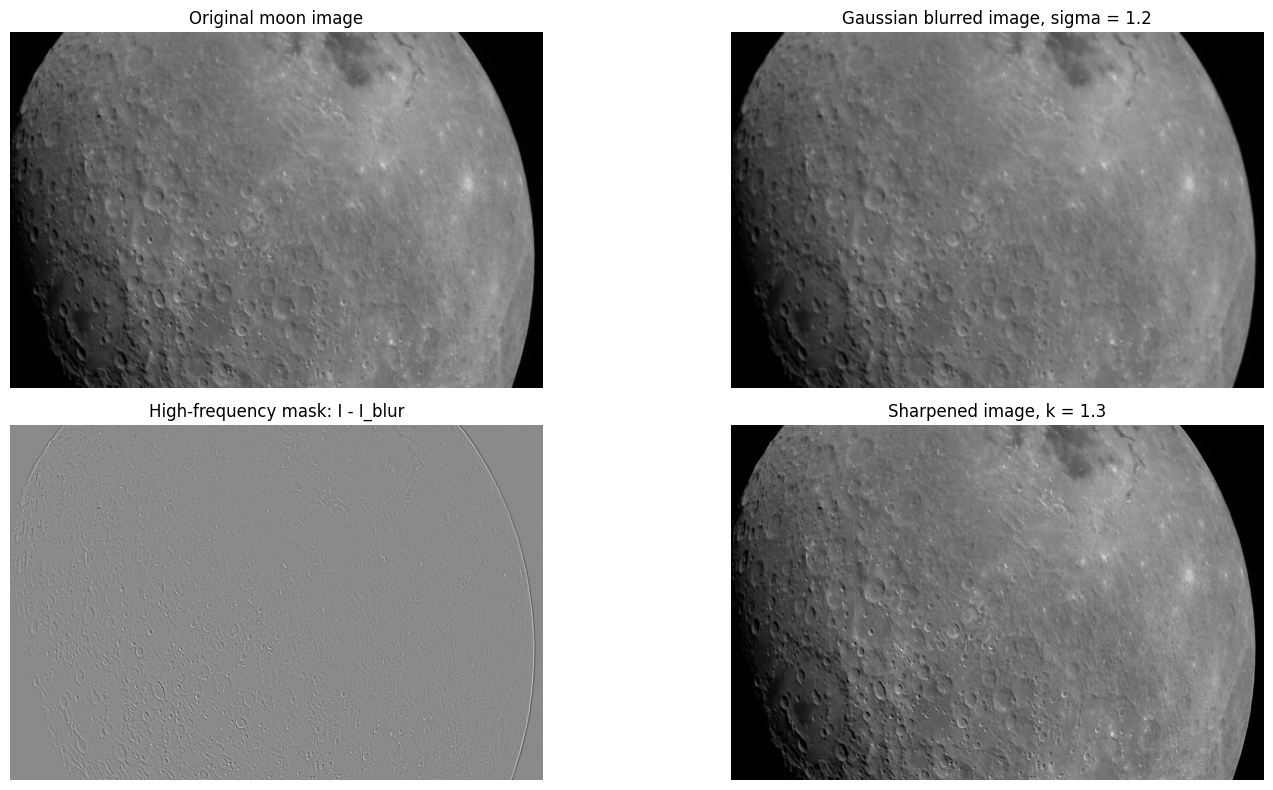

Original image:
Min: 0
Max: 218
Mean: 101.81
Standard deviation: 43.15

Sharpened image:
Min: 0
Max: 252
Mean: 101.32
Standard deviation: 43.63

High-frequency mask:
Mean absolute value: 0.00527

Conclusion:
Gaussian blur estimates the low-frequency component of the moon image.
Subtracting the blurred image gives a high-frequency detail mask.
Adding k times this mask enhances crater borders, surface texture, and local brightness transitions.
Because Gaussian blur is used before extracting details, the sharpening is more controlled than a pure high-pass filter.

Sharpened image saved to:
moon_unsharp_masking_sharpened.jpg


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Exercise 4 - Moon image sharpening
# Method: Unsharp Masking / High-Boost Filtering
# ---------------------------------------------------------

IMAGE_PATH = Path(r"First-photo-of-the-moon-from-Chandrayaan-2_ISRO.jpg")

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

# Safe loading for Windows paths with Unicode / Greek characters
image_bytes = np.fromfile(str(IMAGE_PATH), dtype=np.uint8)
img = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("The image could not be loaded. Check path or file integrity.")

# Convert to float in [0, 1]
I = img.astype(np.float32) / 255.0

# ---------------------------------------------------------
# Parameters
# sigma controls the Gaussian blur
# k controls the amount of sharpening
# ---------------------------------------------------------
sigma = 1.2
k = 1.3

# ---------------------------------------------------------
# 1. Low-frequency component using Gaussian blur
# I_blur = G_sigma * I
# ---------------------------------------------------------
I_blur = cv2.GaussianBlur(I, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)

# ---------------------------------------------------------
# 2. High-frequency mask
# M = I - I_blur
# ---------------------------------------------------------
M = I - I_blur

# ---------------------------------------------------------
# 3. Sharpened image
# I_sharp = I + k * M
# equivalently:
# I_sharp = (1 + k)I - k I_blur
# ---------------------------------------------------------
I_sharp = I + k * M
I_sharp = np.clip(I_sharp, 0, 1)

img_blur = np.clip(I_blur * 255, 0, 255).astype(np.uint8)
img_sharp = np.clip(I_sharp * 255, 0, 255).astype(np.uint8)

# For visualization of the high-frequency mask
M_display = cv2.normalize(M, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ---------------------------------------------------------
# 4. Display results
# ---------------------------------------------------------
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original moon image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img_blur, cmap="gray", vmin=0, vmax=255)
plt.title(f"Gaussian blurred image, sigma = {sigma}")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(M_display, cmap="gray")
plt.title("High-frequency mask: I - I_blur")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_sharp, cmap="gray", vmin=0, vmax=255)
plt.title(f"Sharpened image, k = {k}")
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Numerical confirmation
# ---------------------------------------------------------
print("Original image:")
print("Min:", img.min())
print("Max:", img.max())
print("Mean:", round(float(img.mean()), 2))
print("Standard deviation:", round(float(img.std()), 2))

print("\nSharpened image:")
print("Min:", img_sharp.min())
print("Max:", img_sharp.max())
print("Mean:", round(float(img_sharp.mean()), 2))
print("Standard deviation:", round(float(img_sharp.std()), 2))

print("\nHigh-frequency mask:")
print("Mean absolute value:", round(float(np.mean(np.abs(M))), 5))

print("\nConclusion:")
print("Gaussian blur estimates the low-frequency component of the moon image.")
print("Subtracting the blurred image gives a high-frequency detail mask.")
print("Adding k times this mask enhances crater borders, surface texture, and local brightness transitions.")
print("Because Gaussian blur is used before extracting details, the sharpening is more controlled than a pure high-pass filter.")

# ---------------------------------------------------------
# 6. Save output
# ---------------------------------------------------------
OUTPUT_PATH = IMAGE_PATH.with_name("moon_unsharp_masking_sharpened.jpg")

success, encoded = cv2.imencode(".jpg", img_sharp)

if success:
    encoded.tofile(str(OUTPUT_PATH))
    print(f"\nSharpened image saved to:\n{OUTPUT_PATH}")
else:
    print("\nCould not save the sharpened image.")


## Interpretation of the Unsharp Masking Results

The unsharp masking method first estimates the low-frequency component of the moon image using Gaussian blur:

$$
I_{\text{blur}}=G_{\sigma}*I
$$

This blurred image contains the smooth illumination pattern and the slowly varying gray-level structure of the lunar surface.

Then, the high-frequency mask is computed as:

$$
M=I-I_{\text{blur}}
$$

This mask is not a normal brightness image. It is a difference image and may contain both positive and negative values. Positive values correspond to pixels that are brighter than their local blurred neighborhood, while negative values correspond to pixels that are darker than their local blurred neighborhood.

For visualization only, the mask is normalized to the range 0–255. This displayed mask is used only to show where the high-frequency details are located; it is not used in the sharpening computation.

The final sharpened image is computed as:

$$
I_{\text{sharp}}=I+kM
$$

This means that the extracted high-frequency details are added back to the original image. As a result, crater borders, small lunar surface details, and local brightness transitions become more visible.

The numerical results also support this interpretation. The mean brightness of the sharpened image remains almost unchanged compared with the original image. This is expected because sharpening should mainly enhance local contrast and details, not globally brighten the image.

The standard deviation increases slightly after sharpening. This indicates a small increase in contrast and local intensity variation, which is consistent with enhanced edges and surface texture.

The mean absolute value of the high-frequency mask is small. This means that the extracted detail component has a relatively small average magnitude, so the sharpening is controlled rather than aggressive. In other words, the method enhances the details of the lunar surface without drastically changing the global appearance of the image.

Therefore, unsharp masking is an appropriate main method for this image because it enhances the high spatial frequencies corresponding to lunar craters and surface texture while remaining less aggressive than a pure high-pass or Laplacian-based method.

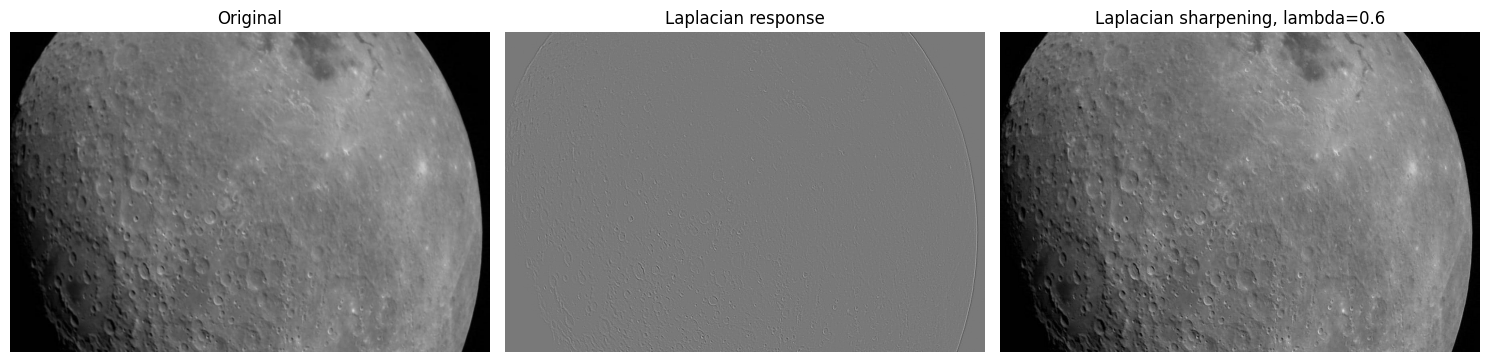

Laplacian sharpening formula:
I_sharp = I + lambda * Laplacian(I)
The Laplacian enhances rapid intensity changes, such as crater edges and fine lunar surface details.
Compared with unsharp masking, it can be more sensitive to noise, so lambda should remain moderate.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Alternative method: Laplacian sharpening
# ---------------------------------------------------------

IMAGE_PATH = Path(r"First-photo-of-the-moon-from-Chandrayaan-2_ISRO.jpg")

image_bytes = np.fromfile(str(IMAGE_PATH), dtype=np.uint8)
img = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image could not be loaded.")

I = img.astype(np.float32) / 255.0

# Laplacian kernel:
# [ 0 -1  0
#  -1  4 -1
#   0 -1  0 ]
kernel = np.array([[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]], dtype=np.float32)

laplacian = cv2.filter2D(I, ddepth=cv2.CV_32F, kernel=kernel)

lambda_value = 0.6

# Since this kernel has positive center, adding the Laplacian sharpens the image
I_lap_sharp = I + lambda_value * laplacian
I_lap_sharp = np.clip(I_lap_sharp, 0, 1)

img_lap_sharp = (I_lap_sharp * 255).astype(np.uint8)
lap_display = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(lap_display, cmap="gray")
plt.title("Laplacian response")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_lap_sharp, cmap="gray", vmin=0, vmax=255)
plt.title(f"Laplacian sharpening, lambda={lambda_value}")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Laplacian sharpening formula:")
print("I_sharp = I + lambda * Laplacian(I)")
print("The Laplacian enhances rapid intensity changes, such as crater edges and fine lunar surface details.")
print("Compared with unsharp masking, it can be more sensitive to noise, so lambda should remain moderate.")


## Alternative Method: Laplacian Sharpening

As an additional comparison, Laplacian sharpening was also implemented.

The Laplacian operator is a second-order derivative operator. In continuous form, it is defined as:

$$
\nabla^2 I=
\frac{\partial^2 I}{\partial x^2}
+
\frac{\partial^2 I}{\partial y^2}
$$

It responds strongly to rapid intensity changes. Therefore, it highlights edges, crater borders, local shadows, and fine surface details.

In the implementation, the following discrete Laplacian kernel is used:

$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

This kernel has a positive center coefficient. It compares the central pixel with its four direct neighbors:

$$
4I(x,y)-I(x-1,y)-I(x+1,y)-I(x,y-1)-I(x,y+1)
$$

Because the center coefficient is positive, sharpening is performed by adding the Laplacian response to the original image:

$$
I_{\text{sharp}}(x,y)=I(x,y)+\lambda \nabla^2 I(x,y)
$$

where:

- $\lambda$ controls the amount of Laplacian sharpening,
- larger $\lambda$ produces stronger sharpening,
- too large $\lambda$ may amplify noise and produce artificial edge artifacts.

In the implementation, the value used is:

$$
\lambda=0.6
$$

This gives a moderate sharpening effect.

The Laplacian response image shows mainly the high-frequency structures of the moon image, such as crater edges and fine local brightness changes. Adding this response to the original image increases the visibility of these structures.

However, compared with unsharp masking, Laplacian sharpening is generally more sensitive to noise because it directly emphasizes second-order intensity changes. It can therefore produce a sharper but potentially more aggressive result.

## Final Conclusion

The proposed main method for sharpening the Chandrayaan-2 moon image is **Unsharp Masking / High-Boost Filtering**.

The method is based on the formula:

$$
I_{\text{sharp}}(x,y)=I(x,y)+k\left[I(x,y)-G_{\sigma}(x,y)\ast I(x,y)\right]
$$

with:

$$
\sigma=1.2
$$

and:

$$
k=1.3
$$

This method is suitable because the important visual information in the moon image consists of crater borders, surface texture, and local brightness transitions, which correspond to high spatial frequencies. Gaussian blurring provides a controlled estimate of the low-frequency component, and subtracting it from the original image extracts the high-frequency detail mask.

The extracted details are then added back to the original image, producing a sharper image while preserving the overall brightness and avoiding excessive artifacts.

Laplacian sharpening was also tested as an alternative method:

$$
I_{\text{sharp}}(x,y)=I(x,y)+\lambda \nabla^2 I(x,y)
$$

with:

$$
\lambda=0.6
$$

This method also enhances crater edges and fine details, but it is more sensitive to noise and can be more aggressive than unsharp masking.

Therefore, the preferred final method is **Unsharp Masking**, while Laplacian sharpening is included as a useful comparison.